In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
import lightgbm as lgb
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import griddata

In [2]:
df = pd.read_csv('..\\data\\segment2.csv')
df.head()

,lat,long,age,q_ihfc,q_ps,q_stein,ps_z,stein_z
0,48.7500,-127.75,2.906279,200.0,277.518538,299.158617,3096.673436,3222.245155
1,47.8983,-127.20,4.359262,161.0,226.597009,244.266377,3230.759601,3362.077870
2,47.8983,-127.65,3.190760,304.0,264.858297,285.511167,3125.194460,3251.988508
3,48.6833,-126.87,5.543758,60.8,200.936360,216.604786,3324.081515,3459.399294
4,48.6850,-126.87,5.543758,63.7,200.936360,216.604786,3324.081515,3459.399294


note that y = df[['ps_q']] will make the shape (#,#) but y = df['ps_q'] will make the shape (#,)

In [ ]:
x = df.drop(columns=['age','ps_z', 'stein_z', 'q_stein', 'q_ps'])
y = df['ps_z']

In [6]:
x.head()

,lat,long,q_ihfc
0,48.7500,-127.75,200.0
1,47.8983,-127.20,161.0
2,47.8983,-127.65,304.0
3,48.6833,-126.87,60.8
4,48.6850,-126.87,63.7


In [7]:
x.shape

(3691, 3)

In [8]:
y.head()

0    3096.673436
1    3230.759601
2    3125.194460
3    3324.081515
4    3324.081515
Name: ps_z, dtype: float64

In [10]:
ts = 0.2

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=ts)

In [11]:
x_train.shape

(2952, 3)

this is the raw validation data

In [12]:
x_test.shape

(739, 3)

In [13]:
x_train.describe().round(3)

,lat,long,q_ihfc
count,2952.000,2952.000,2952.000
mean,48.171,-128.308,1866.649
std,0.323,0.662,17081.465
min,47.686,-129.505,-182.200
25%,47.877,-128.710,200.000
50%,48.299,-128.640,342.500
75%,48.455,-127.785,800.000
max,48.997,-126.223,489000.000


In [14]:
x_test.describe().round(3)

,lat,long,q_ihfc
count,739.000,739.000,739.000
mean,48.170,-128.347,1368.722
std,0.322,0.641,7558.407
min,47.689,-129.492,-10.600
25%,47.895,-128.710,203.000
50%,48.216,-128.640,313.000
75%,48.455,-127.788,687.000
max,48.915,-126.238,180000.000


In [15]:
train_data = lgb.Dataset(x_train, label = y_train)
test_data = lgb.Dataset(x_test, label = y_test)

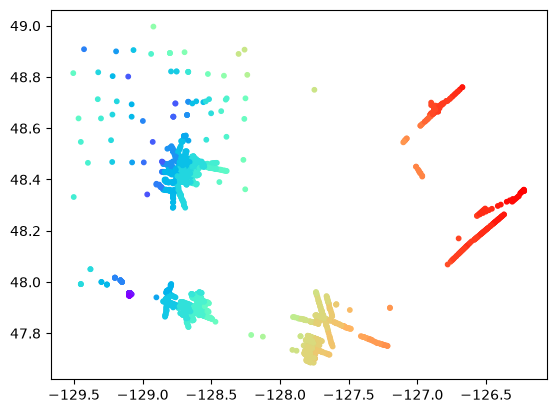

In [16]:
plt.scatter(x_train['long'], x_train['lat'], 
            c=y_train, cmap='rainbow', marker='o', s=10)

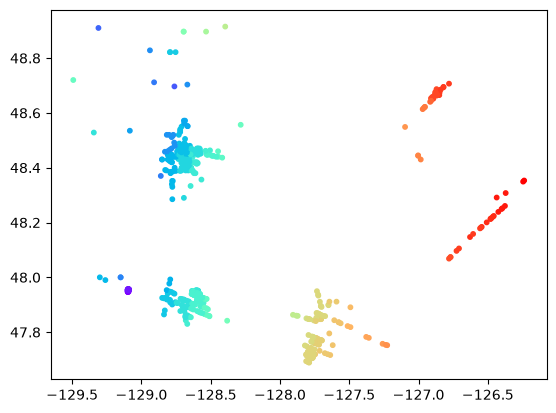

In [17]:
plt.scatter(x_test['long'], x_test['lat'], 
            c=y_test, cmap='rainbow', marker='o', s=10)

In [18]:
lr = 0.1

params = {
    'objective':'regression',
    'metric':'rmse',
    'boosting_type':'gbdt',
    'learning_rate':lr,
    'verbose':1
}

In [19]:
nbr = 100
model = lgb.train(params, train_data, valid_sets = [test_data], num_boost_round=nbr)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.011375 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 765
[LightGBM] [Info] Number of data points in the train set: 2952, number of used features: 3
[LightGBM] [Info] Start training from score 2920.784508


In [20]:
y_pred = model.predict(x_test)

In [21]:
y_pred.shape

(739,)

In [22]:
y_pred, y_pred.shape

(array([2768.01167867, 2842.40631826, 2564.89808042, 3131.00458319,
        3191.02997907, 3146.38300025, 2833.41948785, 3144.03794344,
        2757.65743826, 2785.98737452, 2878.31050134, 2826.3012405 ,
        2706.97793685, 2855.37683896, 2812.0816712 , 2811.75708087,
        3355.48300225, 2827.86605209, 2877.72417809, 2878.33069687,
        3150.27397155, 2855.34727162, 3125.46072646, 3124.76359921,
        2769.03009998, 3153.55649007, 3328.21835085, 2854.2063514 ,
        2799.18832712, 2559.80963284, 2768.45445943, 2878.34697207,
        3142.30526443, 2918.03658276, 2756.21078551, 3340.10790467,
        2772.94829834, 2716.4693789 , 2671.88701496, 2878.49871731,
        3131.01524241, 2833.96056167, 2855.46966512, 2878.24767631,
        2769.26912188, 3124.48288803, 3342.47624527, 2769.26912188,
        2769.26912188, 2771.3201492 , 2769.26912188, 2754.76727197,
        2824.252157  , 2559.64518816, 3131.56793194, 2769.47643799,
        2769.26912188, 3131.00458319, 2878.08700

In [23]:
residuals = y_test - y_pred

negative mean: overpredicting

In [24]:
residuals.head(), residuals.describe()

(2955     1.191308
 1388   -52.632483
 3166    -4.770311
 964      0.076378
 543     -4.589736
 Name: ps_z, dtype: float64,
 count    739.000000
 mean      -0.453717
 std       15.446127
 min     -200.043765
 25%       -0.483291
 50%       -0.002464
 75%        0.408447
 max      113.460292
 Name: ps_z, dtype: float64)

In [25]:
dfr = pd.DataFrame({
    'long': x_test['long'].values,
    'lat': x_test['lat'].values,
    'ps_q_test_data': y_test,
    'ps_q_predicted': y_pred,
    'residual': residuals
})

saving both the csv file and a text file of specified parameters

In [26]:
pd.DataFrame(dfr).to_csv('..\\created_data\\a_seg2_ps_z_residuals.csv', index=False)

with open('..\\created_data\\a_seg2_ps_z_params.txt', 'w') as f:
    f.write('saving parameters for this dataset...\n')
    f.write(f'learning rate: {lr}\nnum_boost_rate: {nbr}\ntest size: {ts}\n')
    f.write(f'gives mean of: {residuals.mean()}')
    f.write(f'and this was for lat, long, and ihfc')

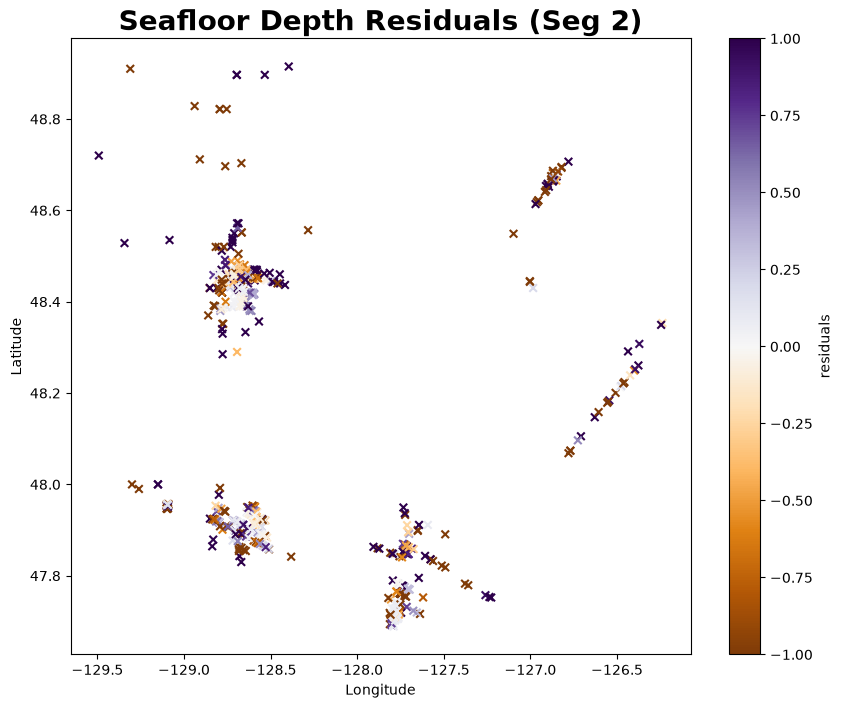

In [28]:
plt.figure(figsize=(10, 8))
plt.scatter(x_test['long'], x_test['lat'], c=residuals, cmap='PuOr',
            marker='x', s=30, vmin=-1, vmax=1)
plt.colorbar(label='residuals')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Seafloor Depth Residuals (Seg 2)', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig('..\\figs\\a_res_ps_z_seg2.png', dpi=400)
plt.show()

## now we ... predict!

In [29]:
sp = 250
grid_long = np.linspace(x_test['long'].min(), x_test['long'].max(), sp)
grid_lat = np.linspace(x_test['lat'].min(), x_test['lat'].max(), sp)

In [30]:
long, lat = np.meshgrid(grid_long, grid_lat)

In [31]:
long.shape, lat.shape

((250, 250), (250, 250))

Nearest copies the value of the closest data point, keeping original values sharp but blocky. Linear blends adjacent points using a straight line or weighted average.

In [33]:
# age_interp = griddata((df['long'], df['lat']), df['age'], (long, lat), method='linear')
hf_interp  = griddata((df['long'], df['lat']), df['q_ihfc'], (long, lat), method='linear')

In [34]:
hf_interp[0:5, 0:5]

array([[nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan],
       [nan, nan, nan, nan, nan]])

In [35]:
hf_interp.shape

(250, 250)

np.vstack stacks arrays as new rows

In [39]:
# lola = np.vstack([long.ravel(), lat.ravel(), age_interp.ravel(), hf_interp.ravel()]).T
lola = np.vstack([long.ravel(), lat.ravel(), hf_interp.ravel()]).T

In [40]:
lola.shape

(62500, 3)

In [41]:
lola_pred = model.predict(lola)

In [42]:
lola_pred[0:5]

array([3367.26527054, 3367.26527054, 3367.26527054, 3367.26527054,
       3367.26527054])

In [43]:
lola_pred = lola_pred.reshape(long.shape)

In [44]:
lola_pred.shape

(250, 250)

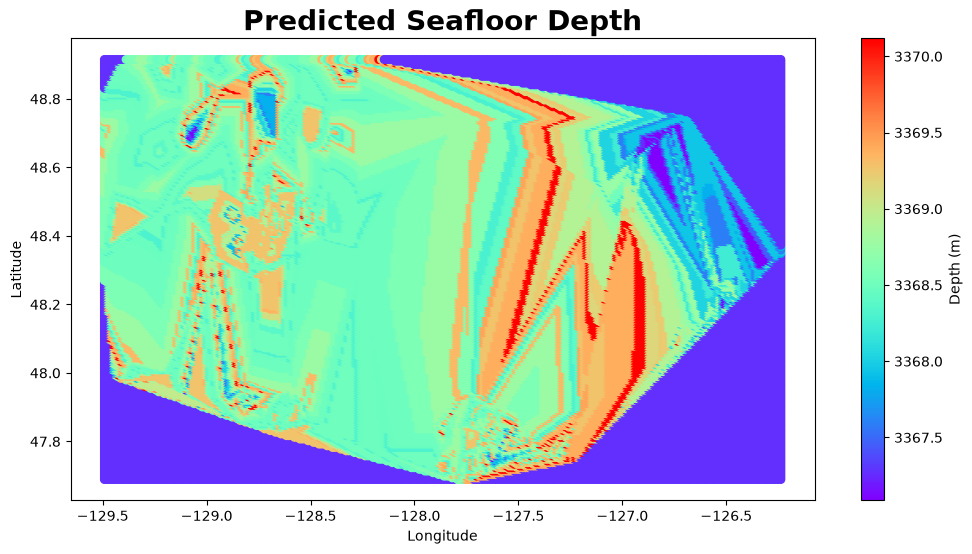

In [45]:
plt.figure(figsize=(12, 6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Depth (m)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Predicted Seafloor Depth', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})

plt.savefig(f'..\\figs\\a_seg2_ps_z_pred_{sp}.png', dpi=400)
plt.show()

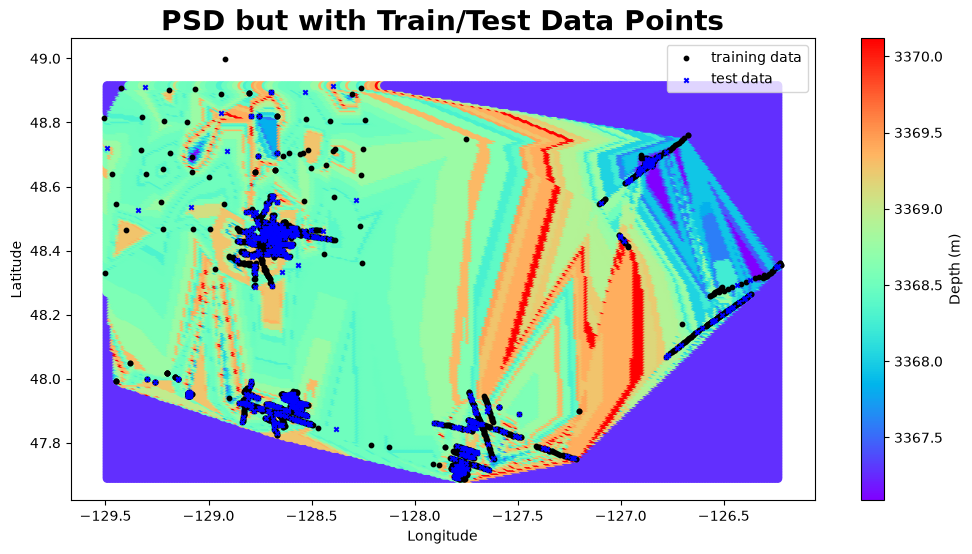

In [46]:
plt.figure(figsize=(12,6))
plt.scatter(long, lat, c=lola_pred, cmap='rainbow', marker='o', s=30)
plt.colorbar(label='Depth (m)')
plt.scatter(x_train['long'], x_train['lat'], marker='o', color='black', s=10, label='training data')
plt.scatter(x_test['long'], x_test['lat'], marker='x', color='blue', s=10, label='test data')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('PSD but with Train/Test Data Points', fontdict={
    'fontsize':20,
    'fontweight':'bold'
})
plt.legend(loc='upper right')

plt.savefig(f'..\\figs\\a_seg2_ps_z_pnts_pred_{sp}.png', dpi=400)
plt.show()